# Wyklad 7: Analiza danych rastrowych w QGIS i Python
### Programowanie w GIS — Kurs dla studentow I stopnia

---

> **Tematy:** Dane rastrowe | PyQGIS | rasterio | NumPy | Kalkulator rastrowy | Statystyki strefowe  
> **Wymagania wstepne:** Wyklad 2 — PyQGIS, podstawy NumPy  

---

### Czym rozni sie raster od wektora — przypomnienie

Dane wektorowe opisuja swiat jako **obiekty** (punkty, linie, poligony).
Dane rastrowe opisuja swiat jako **siatke komorek** (pikseli),
gdzie kazda komorka ma jedna lub wiecej wartosci liczbowych.

```
Wektor:                     Raster:
                            +---+---+---+---+
    /\                      |231|245|198|187|
   /  \                     +---+---+---+---+
  / las\                    |220|234|201|192|
 /______\                   +---+---+---+---+
                            |198|210|245|230|
Jeden obiekt = jeden polygon +---+---+---+---+
                            Jeden piksel = jedna wartosc
```

### Kiedy uzywac danych rastrowych

| Zjawisko | Dlaczego raster |
|---|---|
| Numeryczny Model Terenu (NMT) | Wysokosc jest ciagla — kazdemu punktowi odpowiada jedna wartosc |
| Zobrazowanie satelitarne | Kamera rejestruje swiato w pikselach |
| Temperatura powietrza | Zjawisko cigle, interpolowane na siatke |
| Pokrycie terenu | Klasyfikacja na regularnej siatce |
| Opad atmosferyczny | Mierzone w punktach, interpolowane jako raster |

### Jak korzystac z tego notatnika

Komorki `# [QGIS]` uruchamiaj w Konsoli Pythona QGIS.  
Komorki `# [JUPYTER]` uruchamiaj tutaj — wymagaja `rasterio`, `numpy`, `matplotlib`.

```bash
pip install rasterio numpy matplotlib
```


---
<a id='s1'></a>

## 1. Model danych rastrowych

### 1.1 Podstawowe pojecia

**Piksel** — podstawowa jednostka rastra. Kazdy piksel:

- zajmuje okreslony obszar na ziemi (rozdzielczosc przestrzenna),
- ma jedna lub wiecej wartosci numerycznych (pasma),
- jest prostokątem (najczesciej kwadratem).

**Rozdzielczosc przestrzenna** — rozmiar piksela na ziemi.
Raster 10 m ma piksele pokrywajace 10 m × 10 m.
Im mniejszy piksel, tym wiecej szczegolów — i wiekszy plik.

| Satelita | Rozdzielczosc | Zastosowanie |
|---|---|---|
| Sentinel-2 | 10 m / 20 m / 60 m | Monitoring, rolnictwo |
| Landsat 8/9 | 30 m | Dlugoletni monitoring |
| SPOT-7 | 1.5 m | Szczegolowe mapy |
| Drone ortofoto | 5–20 cm | Precyzja rolnicza, budowlana |

**Pasmo (band)** — jedna warstwa wartosci. Zobrazowanie RGB ma 3 pasma.
Satelita Sentinel-2 ma 13 pasm (rozny zakres spektralny).

### 1.2 Wspolrzedne rastra — geotransformacja

Dane wektorowe określają swoje położenie na Ziemi, bo każdy punkt ma zapisane współrzędne geograficzne. Raster działa inaczej — to zwykła siatka liczb, jak arkusz kalkulacyjny.

Żeby raster miał sens przestrzenny, potrzebuje georeferencji — informacji łączącej numery wierszy i kolumn siatki z rzeczywistymi współrzędnymi na Ziemi.

Geotransformacja to ogólny standard GIS, a nie cecha konkretnego oprogramowania. Stosuje go QGIS, rasterio, GDAL, ArcGIS i każde inne narzędzie GIS pracujące z rastrami. Zapis geotransformacji jest częścią formatu pliku — np. w GeoTIFF jest zapisana w nagłówku pliku, dlatego plik "wie" gdzie leży niezależnie od tego jakim programem go otworzysz.

Geotransformacja to krotka sześciu liczb (standard GDAL):

(x_lewy_gory, rozdzielczosc_x, obrot_x,
 y_gory,       obrot_y,        -rozdzielczosc_y)

Dla zdecydowanej większości rastrów obrot_x = obrot_y = 0 — raster jest wyrównany do osi współrzędnych i nie jest obrócony. Dlatego w praktyce liczy się tylko cztery wartości:

    x_lewy_gory — współrzędna X lewego górnego rogu rastra
    y_gory — współrzędna Y lewego górnego rogu rastra
    rozdzielczosc_x — szerokość jednego piksela w jednostkach CRS
    -rozdzielczosc_y — wysokość piksela, ujemna bo oś Y rośnie w górę a wiersze są numerowane od góry w dół

Każde narzędzie GIS odczytuje tę samą geotransformację z pliku, tylko pokazuje ją trochę inaczej:

```
# GDAL / rasterio — krotka 6 liczb
src.transform
# Affine(0.1, 0.0, 14.1,
#        0.0, -0.1, 55.0)

# PyQGIS — osobne metody
layer.rasterUnitsPerPixelX()   # rozdzielczosc_x
layer.rasterUnitsPerPixelY()   # rozdzielczosc_y (zwraca wartosc dodatnia)
layer.extent().xMinimum()      # x_lewy_gory
layer.extent().yMaximum()      # y_gory
```
To są dwa różne interfejsy do tej samej informacji zapisanej w pliku.

### 1.3 Wartosc NoData

Nie kazdy piksel ma sensowna wartosc — poza obszarem pomiaru
lub tam gdzie dane sa niedostepne, uzywana jest wartosc **NoData**.
Typowe wartosci: `-9999`, `-32768`, `255`, `nan`.

Kluczowe: NoData **nie jest zerem**. Nalezy ja traktowac jak brak danych,
nie jak wartosc. Wiele bledow analitycznych pochodzi z ignorowania NoData.

### 1.4 Popularne formaty rastrowe

| Format | Rozszerzenie | Uwagi |
|---|---|---|
| GeoTIFF | `.tif`, `.tiff` | Standard — geotransformacja wbudowana w plik |
| Cloud Optimized GeoTIFF | `.tif` (COG) | Zoptymalizowany do streamingu z serwera |
| NetCDF | `.nc` | Dane naukowe, czas jako wymiar |
| HDF5 | `.h5`, `.hdf` | Duze dane satelitarne |
| ASCII Grid | `.asc` | Prosty format tekstowy, przestarzaly |
| JPEG2000 | `.jp2` | Kompresja stratna, Sentinel-2 |

Na tym wykladzie uzywamy **GeoTIFF** — jest jednym z najpopularniejszych formatów.


---
<a id='s2'></a>

## 2. Wczytywanie rastra w PyQGIS — QgsRasterLayer

### 2.1 Klasa QgsRasterLayer

`QgsRasterLayer` to odpowiednik `QgsVectorLayer` dla danych rastrowych.
Dziedziczy po `QgsMapLayer` i dodaje metody specyficzne dla rastrow.

### 2.2 Wczytanie pliku

```python
# [QGIS] Wczytaj raster z pliku
from qgis.core import QgsRasterLayer, QgsProject

sciezka = 'C:/sample.tif'   # zmien na swoja sciezke

raster = QgsRasterLayer(sciezka, 'NMT', 'gdal')
#                        ^sciezka  ^nazwa  ^dostawca

if raster.isValid():
    print('Raster wczytany poprawnie!')
    QgsProject.instance().addMapLayer(raster)
else:
    print(f'Blad wczytywania: {raster.error().message()}')
```

<img src="raster1.png" />

### 2.3 Podstawowe metadane

```python
# [QGIS] Metadane rastra
raster = iface.activeLayer()  # zaznacz warstwe rastrowa w Panelu warstw

print(f'Nazwa          : {raster.name()}')
print(f'CRS            : {raster.crs().authid()}')
print(f'Liczba pasm    : {raster.bandCount()}')
print(f'Szerokosc (px) : {raster.width()}')
print(f'Wysokosc  (px) : {raster.height()}')

# Rozdzielczosc
print(f'Rozdzielczosc X: {raster.rasterUnitsPerPixelX():.4f}')
print(f'Rozdzielczosc Y: {raster.rasterUnitsPerPixelY():.4f}')

# Zasieg
ext = raster.extent()
print(f'xMin: {ext.xMinimum():.4f}')
print(f'xMax: {ext.xMaximum():.4f}')
print(f'yMin: {ext.yMinimum():.4f}')
print(f'yMax: {ext.yMaximum():.4f}')
```
<img src="raster5.png" />
<img src="raster3.png" />
<img src="raster4.png" />

### 2.4 Statystyki pasma

```python
# [QGIS] Statystyki wartosci pikseli
from qgis.core import QgsRasterBandStats

raster = iface.activeLayer()
numer_pasma = 1  # pasma numerowane od 1

stats = raster.dataProvider().bandStatistics(
    numer_pasma,
    QgsRasterBandStats.All
)

print(f'Minimum  : {stats.minimumValue:.2f}')
print(f'Maksimum : {stats.maximumValue:.2f}')
print(f'Srednia  : {stats.mean:.2f}')
print(f'Odch.std : {stats.stdDev:.2f}')
```
<img src="raster6.png" />
<img src="raster2.png" />

### 2.5 Odczyt wartosci w punkcie

```python
# [QGIS] Odczytaj wartosc piksela w danym punkcie
from qgis.core import QgsPointXY

raster = iface.activeLayer()

# Wspolrzedne punktu (musza byc w CRS rastra)
punkt = QgsPointXY(17.038, 51.108)   # Wroclaw

wynik, ok = raster.dataProvider().sample(punkt, 1)  # 1 = numer pasma

if ok:
    print(f'Wartosc w punkcie: {wynik:.2f}')
else:
    print('Punkt poza zasiegiem rastra lub wartosc NoData')
```

### 2.6 Informacje o kazdym pasmie

```python
# [QGIS] Przejdz przez wszystkie pasma
raster = iface.activeLayer()

print(f'Raster ma {raster.bandCount()} pasm:')
for i in range(1, raster.bandCount() + 1):
    nazwa = raster.dataProvider().generateBandName(i)
    typ   = raster.dataProvider().dataType(i)
    print(f'  Pasmo {i}: {nazwa} (typ danych: {typ})')
```
<img src="raster7.png" />


---
<a id='s3'></a>

## 3. Wczytywanie rastra w rasterio

### 3.1 Czym jest rasterio

`rasterio` to biblioteka Pythona do odczytu i zapisu danych rastrowych.
Dziala niezaleznie od QGIS, na bazie biblioteki GDAL.
Zwraca dane jako tablice NumPy — mozna na nich wykonywac dowolne obliczenia.

https://rasterio.readthedocs.io/en/latest/index.html

### 3.2 Podstawowy odczyt

```python
import rasterio
import numpy as np

# Otwarcie pliku (jak open() dla zwyklych plikow)
with rasterio.open('sample.tif') as src:

    # Metadane
    print(src.crs)          # uklad wspolrzednych
    print(src.count)        # liczba pasm
    print(src.width)        # szerokosc w pikselach
    print(src.height)       # wysokosc w pikselach
    print(src.dtypes)       # typy danych per pasmo
    print(src.nodata)       # wartosc NoData
    print(src.transform)    # geotransformacja
    print(src.bounds)       # zasieg (left, bottom, right, top)

    # Odczyt danych jako tablica NumPy
    pasmo1 = src.read(1)        # jedno pasmo, shape: (height, width)
    wszystkie = src.read()      # wszystkie pasma, shape: (count, height, width)

print(type(pasmo1))             # numpy.ndarray
print(pasmo1.shape)             # (height, width)
print(pasmo1.dtype)             # int16, float32, uint8...
```

### 3.3 Maska NoData

```python
with rasterio.open('nmt.tif') as src:
    dane = src.read(1)              # surowe dane z NoData
    maska = src.dataset_mask()      # 0 = NoData, 255 = dane

    # Zamien NoData na NaN (dla float)
    dane_float = dane.astype(float)
    dane_float[maska == 0] = np.nan

    # Obliczenia tylko na poprawnych pikselach
    print(f'Srednia (z NaN): {np.nanmean(dane_float):.2f}')
    print(f'Pikselei NoData: {np.sum(maska == 0)}')
```

### 3.4 Przeliczanie wspolrzednych

```python
from rasterio.transform import rowcol, xy

with rasterio.open('nmt.tif') as src:
    # Wspolrzedne geograficzne -> numer wiersza i kolumny
    row, col = rowcol(src.transform, 17.038, 51.108)
    print(f'Wroclaw: wiersz={row}, kolumna={col}')

    # Wartosc w tym pikselu
    dane = src.read(1)
    print(f'Wartosc NMT w Wroclawiu: {dane[row, col]}')

    # Numer wiersza/kolumny -> wspolrzedne centrum piksela
    lon, lat = xy(src.transform, row, col)
    print(f'Centrum piksela: lon={lon:.4f}, lat={lat:.4f}')
```


In [1]:
import rasterio
import numpy as np

# Otwarcie pliku (jak open() dla zwyklych plikow)
with rasterio.open('sample.tif') as src:

    # Metadane
    print(src.crs)          # uklad wspolrzednych
    print(src.count)        # liczba pasm
    print(src.width)        # szerokosc w pikselach
    print(src.height)       # wysokosc w pikselach
    print(src.dtypes)       # typy danych per pasmo
    print(src.nodata)       # wartosc NoData
    print(src.transform)    # geotransformacja
    print(src.bounds)       # zasieg (left, bottom, right, top)

    # Odczyt danych jako tablica NumPy
    pasmo1 = src.read(1)        # jedno pasmo, shape: (height, width)
    wszystkie = src.read()      # wszystkie pasma, shape: (count, height, width)

print(type(pasmo1))             # numpy.ndarray
print(pasmo1.shape)             # (height, width)
print(pasmo1.dtype)             # int16, float32, uint8...

PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
3
1001
1001
('uint16', 'uint16', 'uint16')
None
| 10.00, 0.00, 590520.00|
| 0.00,-10.00, 5790630.00|
| 0.00, 0.00, 1.00|
BoundingBox(left=590520.0, bottom=5780620.0, right=600530.0, top=5790630.0)
<class 'numpy.ndarray'>
(1001, 1001)
uint16


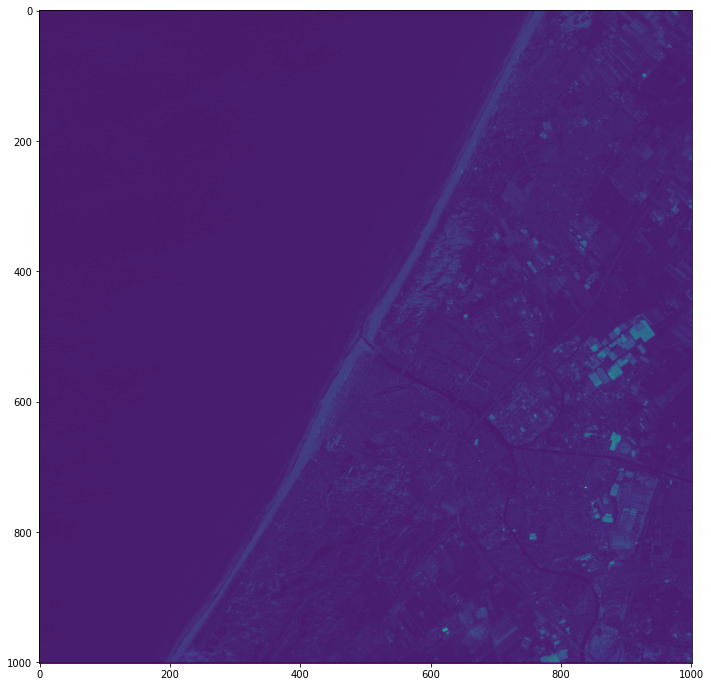

In [2]:
import matplotlib.pyplot as plt
with rasterio.open('sample.tif') as src:
    plt.figure(figsize=(12,12))
    plt.imshow(src.read(1))

In [3]:
with rasterio.open('sample.tif') as src:
    dane = src.read(1)              # surowe dane z NoData
    maska = src.dataset_mask()      # 0 = NoData, 255 = dane

    # Zamien NoData na NaN (dla float)
    dane_float = dane.astype(float)
    dane_float[maska == 0] = np.nan

    # Obliczenia tylko na poprawnych pikselach
    print(f'Srednia (z NaN): {np.nanmean(dane_float):.2f}')
    print(f'Pikselei NoData: {np.sum(maska == 0)}')

Srednia (z NaN): 1009.32
Pikselei NoData: 0


In [4]:
from rasterio.transform import rowcol, xy

with rasterio.open('sample.tif') as src:
    # Wspolrzedne geograficzne -> numer wiersza i kolumny
    row, col = rowcol(src.transform, 597561, 5785199)
    print(f'wiersz={row}, kolumna={col}')

    # Wartosc w tym pikselu
    dane = src.read(1)
    print(f'Wartosc rastra: {dane[row, col]}')

    # Numer wiersza/kolumny -> wspolrzedne centrum piksela
    lon, lat = xy(src.transform, row, col)
    print(f'Centrum piksela: lon={lon:.4f}, lat={lat:.4f}')

wiersz=543, kolumna=704
Wartosc rastra: 1197
Centrum piksela: lon=597565.0000, lat=5785195.0000


---
<a id='s4'></a>

## 4. Operacje na pasmach i pikselach — NumPy

### 4.1 Dlaczego NumPy

Raster wczytany przez rasterio to tablica NumPy.
NumPy pozwala wykonywac operacje na milionach pikseli naraz, co jest znacznie szybsze niz petla po kazdym pikselu (algebra liniowa).

Przyklad: raster 1000×1000 pikseli ma 1 000 000 komorek.
Petla Python: kilka sekund. Operacja NumPy: ulamek sekundy.

### 4.2 Podstawowe operacje arytmetyczne

```python
import numpy as np

# dane to tablica NumPy shape (height, width)
# Kazda operacja dziala na kazdym pikselu jednoczesnie

# Przeliczenie metrow na stopy (jeśli to na przykład NMT)
dane_stopy = dane * 3.28084

# Normalizacja do zakresu 0-1
dane_norm = (dane - dane.min()) / (dane.max() - dane.min())

# Dodanie stalej do kazdego piksela
dane_przesuniete = dane + 100

# Pierwiastek kwadratowy z kazdego piksela
dane_sqrt = np.sqrt(np.maximum(dane, 0))  # maximum by uniknac ujemnych
```

### 4.3 Operacje miedzy pasmami — przykład NDVI

NDVI (Normalized Difference Vegetation Index) to klasyczny wskaznik
zdrowia roslinnosci obliczany z danych wielospektralnych:

```
NDVI = (NIR - RED) / (NIR + RED)
```

gdzie NIR = pasmo bliskiej podczerwieni, RED = pasmo czerwone.
NDVI przyjmuje wartosci od -1 do 1:

| Wartosc | Interpretacja |
|---|---|
| > 0.6 | Gesta roslinnosc (las) |
| 0.2 – 0.6 | Roslinnosc rozrzedzona (trawy, uprawy) |
| 0.0 – 0.2 | Slaba roslinnosc lub gleba |
| < 0.0 | Woda, snieg, skaly |

```python
with rasterio.open('sentinel2.tif') as src:
    # Sentinel-2: pasmo 4 = RED, pasmo 8 = NIR
    red = src.read(4).astype(float)
    nir = src.read(8).astype(float)

# Unikamy dzielenia przez zero
mianownik = nir + red
ndvi = np.where(
    mianownik != 0,
    (nir - red) / mianownik,
    np.nan
)

print(f'NDVI min: {np.nanmin(ndvi):.3f}')
print(f'NDVI max: {np.nanmax(ndvi):.3f}')
print(f'NDVI mean: {np.nanmean(ndvi):.3f}')
```

### 4.4 Filtrowanie pikseli — maski logiczne

```python
# Znajdz piksele wyzsze niz 500 m
maska_wysokie = dane > 500
print(f'Pikseli > 500m: {maska_wysokie.sum()}')

# Oblicz srednia tylko dla wysokich terenow
srednia_wysokie = dane[maska_wysokie].mean()
print(f'Srednia wysokosc terenow > 500m: {srednia_wysokie:.1f}')

# Pokoloruj piksele NoData na zero
dane_clean = dane.copy()
dane_clean[dane == -9999] = 0

# Znajdz piksele w zakresie 200-500 m
niziny = (dane >= 0) & (dane <= 200)
print(f'Procent nizin: {niziny.mean() * 100:.1f}%')
```


In [5]:
import matplotlib.pyplot as plt
with rasterio.open('sample.tif') as src:
    # tylko przykład, to nie NDVI
    red = src.read(1).astype(float)
    nir = src.read(3).astype(float)

# Unikamy dzielenia przez zero
mianownik = nir + red
ndvi = np.where(
    mianownik != 0,
    (nir - red) / mianownik,
    np.nan
)

print(f'NDVI min: {np.nanmin(ndvi):.3f}')
print(f'NDVI max: {np.nanmax(ndvi):.3f}')
print(f'NDVI mean: {np.nanmean(ndvi):.3f}')

plt.figure(figsize=(12,12))
pyplot.imshow(ndvi)
pyplot.show()

NDVI min: -0.674
NDVI max: 0.471
NDVI mean: -0.217


C:\Users\kamil\AppData\Local\Temp\ipykernel_32776\1211238594.py:11: RuntimeWarning: invalid value encountered in divide
  (nir - red) / mianownik,


NameError: name 'pyplot' is not defined

<Figure size 864x864 with 0 Axes>

---

### Jak wykonac te same operacje w QGIS

#### Kalkulator rastrowy — interfejs graficzny

Wszystkie operacje arytmetyczne na pasmach mozna wykonac przez:
`Raster -> Kalkulator rastrowy`

<img src="raster8.png"/>
Skladnia nazwy pasma w kalkulatorze:

```
"nazwa_warstwy@numer_pasma"
```

Nazwy dostepnych warstw i pasm widac w panelu po lewej stronie —
mozna je klikac zamiast wpisywac recznie.

**NDVI:**
```
("sentinel2@4" - "sentinel2@3") / ("sentinel2@4" + "sentinel2@3")
```

**Maska logiczna** — piksele w zakresie 200–500 m:
```
("nmt@1" >= 200) AND ("nmt@1" < 500)
```
Wynik: raster z wartosciami 0 (falsz) i 1 (prawda).

**Przeliczenie metrow na stopy:**
```
"nmt@1" * 3.28084
```

**Normalizacja 0–1** (gdy znasz min i max z wlasciwosci warstwy):
```
("nmt@1" - 80) / (280 - 80)
```

#### Statystyki pasma — przez wlasciwosci warstwy

1. Kliknij dwukrotnie warstwe rastrowa w Panelu warstw
2. Zakladka **Histogram** -> kliknij `Oblicz histogram`
3. Zakladka **Informacje** -> sekcja `Statystyki pasma`

Lub przez Processing:
`Przetwarzanie -> Skrzynka narzedzi -> QGIS -> Statystyki rastra`


#### Kalkulator ratrowy - PyQGIS

W PyQGIS wykonujemy te operacje za pomocą processingu. 

**UWAGA**: To pierwszy raz kiedy processing pojawia się na wykładach. Może też być wykorzystywany do przetwarzania innych danych, w tym wektorowych. Tutaj spojrzymy na dane rastrowe.

Wszelkie funkcje processing uruchamiamy poleceniem

```processing.run()```
Każdy processing ma swoje konkretne parametry. Przykładowo kalkulator rastra wywołujemy

```
processing.run('qgis:rastercalculator', {parametry})
```
Przykładowo
```
raster = iface.activeLayer()
nazwa  = raster.name()

ndvi = processing.run('qgis:rastercalculator', {
    'EXPRESSION': f'("{nazwa}@1" - "{nazwa}@3") / ("{nazwa}@1" + "{nazwa}@3")',
    'LAYERS'    : [raster],
    'CELLSIZE'  : 0,
    'EXTENT'    : None,
    'CRS'       : raster.crs(),
    'OUTPUT'    : 'TEMPORARY_OUTPUT'
})

ndvi_path = ndvi['OUTPUT']
ndvi_layer = QgsRasterLayer(ndvi_path, 'NDVI')


if ndvi_layer.isValid():
    QgsProject.instance().addMapLayer(ndvi_layer)
    print('NDVI obliczony i dodany do projektu.')
else:
    print('Błąd tworzenia warstwy NDVI.')
```

Inne przykłady:
```
# --- Maska logiczna: piksele powyzej 500m ---
# (zakladamy ze pasmo 1 to NMT w metrach)
maska = processing.run('qgis:rastercalculator', {
    'EXPRESSION': f'"{nazwa}@1" > 500',
    'LAYERS'    : [raster],
    'CELLSIZE'  : 0,
    'EXTENT'    : None,
    'CRS'       : raster.crs(),
    'OUTPUT'    : 'TEMPORARY_OUTPUT'
})
maska_layer = maska['OUTPUT']
maska_layer.setName('Maska_powyzej_500m')
QgsProject.instance().addMapLayer(maska_layer)
print('Maska logiczna dodana do projektu.')

# --- Statystyki pasma przez PyQGIS ---
from qgis.core import QgsRasterBandStats

print(f'\nStatystyki pasm warstwy: {raster.name()}')
print(f'{"Pasmo":<8} {"Min":>10} {"Max":>10} {"Srednia":>10} {"Std":>10}')
print('-' * 52)
for i in range(1, raster.bandCount() + 1):
    stats = raster.dataProvider().bandStatistics(
        i, QgsRasterBandStats.All
    )
    print(f'{i:<8} {stats.minimumValue:>10.3f} {stats.maximumValue:>10.3f}'
          f' {stats.mean:>10.3f} {stats.stdDev:>10.3f}')

# --- Przeliczenie metrow na stopy (pasmo 1) ---
stopy = processing.run('qgis:rastercalculator', {
    'EXPRESSION': f'"{nazwa}@1" * 3.28084',
    'LAYERS'    : [raster],
    'CELLSIZE'  : 0,
    'EXTENT'    : None,
    'CRS'       : raster.crs(),
    'OUTPUT'    : 'TEMPORARY_OUTPUT'
})
stopy_layer = stopy['OUTPUT']
stopy_layer.setName('NMT_stopy')
QgsProject.instance().addMapLayer(stopy_layer)
print('\nPasmo 1 przeliczone na stopy i dodane do projektu.')

iface.mapCanvas().refresh()
```

---
<a id='s5'></a>

## 5. Przycinanie rastra do obszaru — clip by mask

### 5.1 Po co przycinamy

Dane rastrowe czesto pokrywaja wiekszy obszar niz potrzebujemy.
Satelitarne sceny pokrywaja setki km². Jezeli interesuje nas
tylko jeden powiat, przycinamy raster do jego granicy.

Efekty przycinania:

- mniejszy plik — szybszy odczyt i obliczenia,
- wyniki analizy ograniczone do obszaru zainteresowania,
- piksele poza obszarem maskowane jako NoData.

### 5.2 Przycinanie w PyQGIS przez Processing

```python
# [QGIS] Przytnij raster do granicy warstwy wektorowej
import processing

raster  = QgsProject.instance().mapLayersByName('NMT')[0]
maska   = QgsProject.instance().mapLayersByName('granica_obszaru')[0]

wynik = processing.run('gdal:cliprasterbymasklayer', {
    'INPUT'   : raster,
    'MASK'    : maska,
    'NODATA'  : -9999,
    'CROP_TO_CUTLINE': True,    # przytnij do bounding box maski
    'KEEP_RESOLUTION': True,    # zachowaj oryginalna rozdzielczosc
    'OUTPUT'  : 'TEMPORARY_OUTPUT'
})

raster_przyciety_sciezka = wynik['OUTPUT']

```

### 5.3 Przycinanie przez prostokat (bbox)

```python
# [QGIS] Szybsze przycinanie — przez prostokat
import processing

raster = QgsProject.instance().mapLayersByName('NMT')[0]

wynik = processing.run('gdal:cliprasterbyextent', {
    'INPUT'  : raster,
    'PROJWIN': '16.8,17.3,50.9,51.3',  # xmin,xmax,ymin,ymax
    'NODATA' : -9999,
    'OUTPUT' : 'TEMPORARY_OUTPUT'
})
```

### 5.4 Przycinanie w rasterio

#### Pryzcięcie indeksami

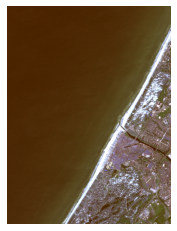

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

r0, r1 = 20, 900
c0, c1 = 40, 700

with rasterio.open("sample.tif") as src:
    window = Window(c0, r0, c1-c0, r1-r0)
    data = src.read([1, 2, 3], window=window)

rgb = np.moveaxis(data, 0, -1)

img = rgb.astype(float)

p2, p98 = np.percentile(img, (2, 98))

img = np.clip(img, p2, p98)
img = (img - p2) / (p98 - p2)

plt.imshow(img)
plt.axis("off")
plt.show()

#### Przycięcie shapefile'm

C:\Users\kamil\AppData\Roaming\Python\Python39\site-packages\geopandas\array.py:334: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
C:\Users\kamil\AppData\Roaming\Python\Python39\site-packages\geopandas\geodataframe.py:409: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  level.crs = crs


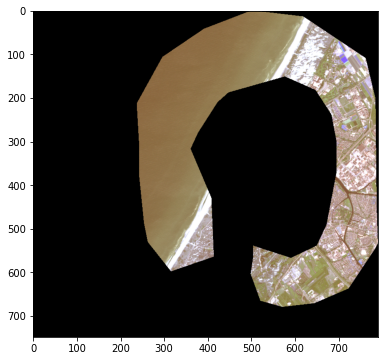

In [92]:
import rasterio
import rasterio.mask
import geopandas as gpd

gdf = gpd.read_file("wektor_przycięcia.shp")

with rasterio.open("sample.tif") as src:

    out_image, out_transform = rasterio.mask.mask(
        src,
        gdf.geometry,
        crop=True
    )

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    with rasterio.open("sample_clip.tif", "w", **out_meta) as dest:
        dest.write(out_image)
        
img = np.moveaxis(out_image[:3], 0, -1)

# normalizacja do 0–1, żeby dobrze się wyświetlało

img = img.astype(float)

p2, p98 = np.percentile(img, (2, 98))

img = np.clip(img, p2, p98)
img = (img - p2) / (p98 - p2)

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.show()

---
<a id='s6'></a>

## 6. Reklasyfikacja

### 6.1 Czym jest reklasyfikacja

Reklasyfikacja (ang. *reclassify*) zamienia wartosci ciagłe
na kategorie dyskretne. Przyklad:

```
Wartosc NMT    ->  Klasa
0   – 200 m        1  (niziny)
200 – 500 m        2  (wyzyny)
500 – 1500 m       3  (gory niskie)
> 1500 m           4  (gory wysokie)
```

### 6.2 Reklasyfikacja w PyQGIS przez Processing

```python
# [QGIS] Reklasyfikuj NMT na klasy wysokosciowe
import processing

raster = iface.activeLayer()

# Tabela reklasyfikacji: [[min, max, nowa_wartosc], ...]
tabela = [
    [0,    200,  1],   # niziny
    [200,  500,  2],   # wyzyny
    [500,  1300, 3],   # gory niskie
    [1300, 9999, 4],   # gory wysokie
]

wynik = processing.run('native:reclassifybytable', {
    'INPUT_RASTER'    : raster,
    'RASTER_BAND'     : 1,
    'TABLE'           : [v for row in tabela for v in row],
    'NO_DATA'         : -9999,
    'RANGE_BOUNDARIES': 0,      # 0 = min <= x < max
    'NODATA_FOR_MISSING': True,
    'OUTPUT'          : 'TEMPORARY_OUTPUT'
})

reklasy = wynik['OUTPUT']
reklasy_layer = QgsRasterLayer(reklasy, 'reclassfied')
QgsProject.instance().addMapLayer(reklasy_layer)
print('Reklasyfikacja zakonczona.')
```

### 6.3 Reklasyfikacja przez NumPy (rasterio)

```python
import numpy as np

# dane = tablica NumPy z wartosciami NMT
wynik = np.full_like(dane, -9999, dtype=np.int8)  # wypelnij NoData

# Przypisz klasy przez maski logiczne
wynik[(dane >= 0)    & (dane < 200)]  = 1
wynik[(dane >= 200)  & (dane < 500)]  = 2
wynik[(dane >= 500)  & (dane < 1500)] = 3
wynik[dane >= 1500]                   = 4

print(f'Klasa 1 (niziny)    : {(wynik==1).sum()} px')
print(f'Klasa 2 (wyzyny)    : {(wynik==2).sum()} px')
print(f'Klasa 3 (gory niskie): {(wynik==3).sum()} px')
print(f'Klasa 4 (gory wys.) : {(wynik==4).sum()} px')
```

### 6.4 Kalkulator rastrowy w PyQGIS

Kalkulator rastrowy pozwala pisac wyrazenia matematyczne
operujace na pasmach rastra.

```python
# [QGIS] Oblicz nachylenie terenu przez Processing
import processing

nmt = QgsProject.instance().mapLayersByName('NMT')[0]

# Nachylenie terenu
nachylenie = processing.run('gdal:slope', {
    'INPUT'          : nmt,
    'BAND'           : 1,
    'SCALE'          : 1,
    'AS_PERCENT'     : False,  # w stopniach
    'COMPUTE_EDGES'  : True,
    'OUTPUT'         : 'TEMPORARY_OUTPUT'
})

# Ekspozycja terenu (aspect)
ekspozycja = processing.run('gdal:aspect', {
    'INPUT'   : nmt,
    'BAND'    : 1,
    'OUTPUT'  : 'TEMPORARY_OUTPUT'
})

# Cieniowanie rzezby (hillshade)
hillshade = processing.run('gdal:hillshade', {
    'INPUT'       : nmt,
    'BAND'        : 1,
    'Z_FACTOR'    : 2,      # wyolbrzmienie pionowe
    'SCALE'       : 1,
    'AZIMUTH'     : 315,    # kierunek swiatla
    'ALTITUDE'    : 45,     # kat swiatla
    'OUTPUT'      : 'TEMPORARY_OUTPUT'
})

for wynik, nazwa in [
    (nachylenie, 'Nachylenie'),
    (ekspozycja, 'Ekspozycja'),
    (hillshade,  'Cieniowanie')
]:
    w = wynik['OUTPUT']
    w.setName(nazwa)
    QgsProject.instance().addMapLayer(w)

print('Wszystkie pochodne NMT dodane do projektu.')
```


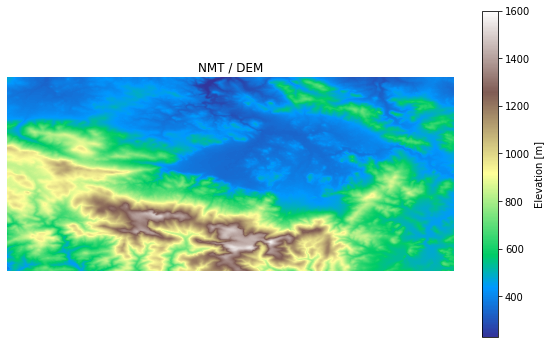

In [98]:
nmt = rasterio.open('SRTM.tif')
data = nmt.read(1)

plt.figure(figsize=(10,6))

plt.imshow(data, cmap='terrain')

plt.colorbar(label="Elevation [m]")

plt.title("NMT / DEM")

plt.axis("off")

plt.show()

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

nmt = data

In [106]:
# Reklasyfikacja
klasy = np.zeros_like(nmt, dtype=np.int8)
klasy[(nmt >= 0)   & (nmt < 200)]  = 1  # niziny
klasy[(nmt >= 200) & (nmt < 500)]  = 2  # wyzyny
klasy[(nmt >= 500) & (nmt < 1000)] = 3  # gory niskie
klasy[nmt >= 1000]                 = 4  # gory wysokie


Text(0.5, 1.0, 'Reklasyfikacja — 4 klasy')

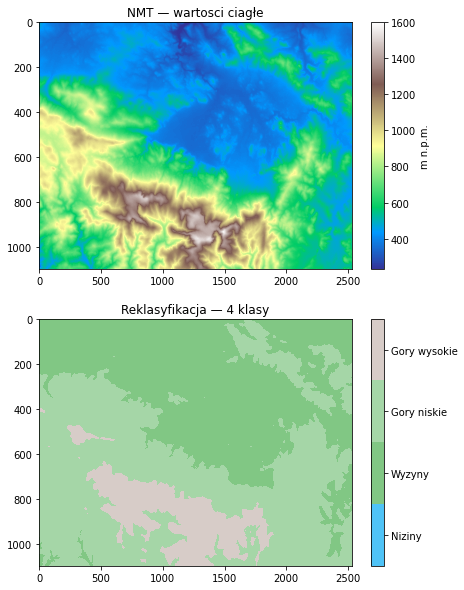

In [107]:
# Wizualizacja
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

im0 = axes[0].imshow(nmt, cmap='terrain', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='m n.p.m.')
axes[0].set_title('NMT — wartosci ciagłe')

cmap_klasy = mcolors.ListedColormap(['#4FC3F7','#81C784','#A5D6A7','#D7CCC8'])
im1 = axes[1].imshow(klasy, cmap=cmap_klasy, aspect='auto', vmin=0.5, vmax=4.5)
cbar = plt.colorbar(im1, ax=axes[1], ticks=[1,2,3,4])
cbar.ax.set_yticklabels(['Niziny', 'Wyzyny', 'Gory niskie', 'Gory wysokie'])
axes[1].set_title('Reklasyfikacja — 4 klasy')

Text(0.5, 1.0, 'Nachylenie terenu (gradient NMT)')

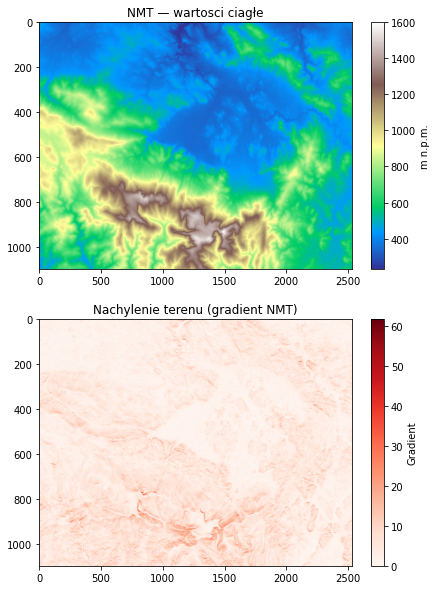

In [108]:
# Nachylenie (gradient)
gy, gx = np.gradient(nmt)
nachylenie = np.sqrt(gx**2 + gy**2)

# Wizualizacja
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

im0 = axes[0].imshow(nmt, cmap='terrain', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='m n.p.m.')
axes[0].set_title('NMT — wartosci ciagłe')

im2 = axes[1].imshow(nachylenie, cmap='Reds', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Gradient')
axes[1].set_title('Nachylenie terenu (gradient NMT)')

Text(0.5, 1.0, 'Cieniowanie rzezby (hillshade)')

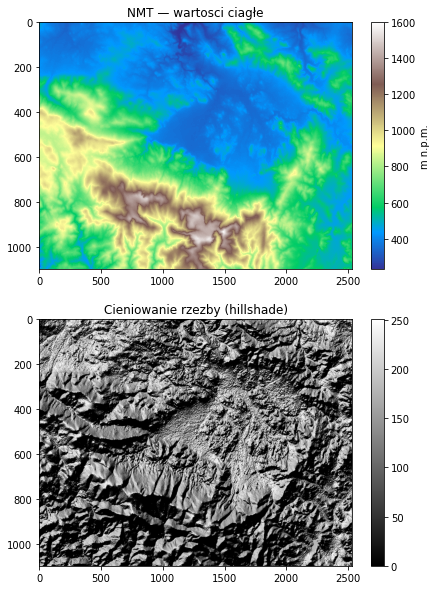

In [109]:
    # Hillshade
az_rad = np.radians(315)
alt_rad = np.radians(45)
hillshade = (np.cos(alt_rad) * np.cos(np.arctan(nachylenie))
             + np.sin(alt_rad) * np.sin(np.arctan(nachylenie))
             * np.cos(az_rad - np.arctan2(-gx, gy)))
hillshade = np.clip(hillshade * 255, 0, 255)

fig, axes = plt.subplots(2, 1, figsize=(7, 10))

im0 = axes[0].imshow(nmt, cmap='terrain', aspect='auto')
plt.colorbar(im0, ax=axes[0], label='m n.p.m.')
axes[0].set_title('NMT — wartosci ciagłe')

im3 = axes[1].imshow(hillshade, cmap='gray', aspect='auto')
plt.colorbar(im3, ax=axes[1])
axes[1].set_title('Cieniowanie rzezby (hillshade)')

---
<a id='s8'></a>

## 8. Eksport i wizualizacja wynikow

### 8.1 Zapis rastra w rasterio

```python
import rasterio

with rasterio.open("SRTM.tif") as src:

    data = src.read()

    profile = src.profile

    with rasterio.open("SRTM_copy.tif", "w", **profile) as dst:
        dst.write(data)

print("Raster zapisany.")
```

### 8.2 Eksport przez PyQGIS

```python
# [QGIS] Zapisz raster tymczasowy do pliku
import processing

raster = iface.activeLayer()

processing.run("gdal:translate", {
    'INPUT': raster,
    'TARGET_CRS': None,
    'NODATA': None,
    'COPY_SUBDATASETS': False,
    'OPTIONS': '',
    'EXTRA': '',
    'DATA_TYPE': 0,
    'OUTPUT': 'C:/temp/output.tif'
})

print("Raster zapisany.")
```

LUB


```
from qgis.core import QgsRasterFileWriter

raster = iface.activeLayer()

pipe = raster.pipe()

writer = QgsRasterFileWriter("C:/temp/output.tif")

writer.writeRaster(
    pipe,
    raster.width(),
    raster.height(),
    raster.extent(),
    raster.crs()
)

print("Raster zapisany.")
```


---
<a id='s9'></a>

## 9. PyQGIS vs rasterio — kiedy co uzywac

| Zadanie | PyQGIS | rasterio |
|---|---|---|
| Wczytanie rastra do projektu QGIS | Tak — `QgsRasterLayer` | Nie |
| Odczyt wartosci w punkcie | Tak — `dataProvider().sample()` | Tak — przez transformacje |
| Statystyki pasma | Tak — `bandStatistics()` | Tak — przez NumPy |
| Clip by mask | Tak — `gdal:cliprasterbymasklayer` | Tak — `rasterio.mask` |
| Reklasyfikacja | Tak — `native:reclassifybytable` | Tak — maski NumPy |
| Zonal statistics | Tak — `native:zonalstatisticsfb` | Tak — petla + mask |
| Obliczenia arytmetyczne (NDVI) | Tak — kalkulator rastrowy | Tak — NumPy (szybciej) |
| Hillshade, slope, aspect | Tak — `gdal:hillshade` itd. | Mozliwe — NumPy (trudniej) |
| Praca bez QGIS (serwer, Jupyter) | Nie | Tak |
| Integracja z data science | Slaba | Doskonala (pandas, sklearn) |
| Wizualizacja | QGIS Canvas | Matplotlib (wiecej kontroli) |

### Zasada

Jezeli pracujesz wewnatrz projektu QGIS i potrzebujesz
algorytmow Processing Toolbox — uzyj **PyQGIS**.

Jezeli robisz skomplikowane obliczenia numeryczne,
pracujesz w Jupyter lub na serwerze — uzyj **rasterio + NumPy**.

W praktyce czesto laczymy oba: PyQGIS do wczytania i clipowania,
rasterio do obliczen, PyQGIS ponownie do zapisu i wizualizacji.


---
<a id='s10'></a>

## 10. Podsumowanie i slownik pojec

### Co omowilismy

- model danych rastrowych: piksel, pasmo, rozdzielczosc, NoData, geotransformacja,
- wczytywanie rastra przez `QgsRasterLayer` i `rasterio.open()`,
- odczyt metadanych: CRS, liczba pasm, rozdzielczosc, zasieg, statystyki,
- odczyt wartosci w punkcie przez `dataProvider().sample()` i `rowcol()`,
- operacje NumPy na pikselach: arytmetyka, maski logiczne, NDVI,
- przycinanie do obszaru: `gdal:cliprasterbymasklayer` i `rasterio.mask`,
- reklasyfikacja: `native:reclassifybytable` i maski NumPy,
- pochodne NMT: nachylenie, ekspozycja, hillshade przez Processing,
- zapis rastra i wizualizacja w Matplotlib.

### Slownik pojec

| Pojecie | Definicja |
|---|---|
| **Piksel** | Podstawowa komorka rastra przechowujaca wartosc numeryczna |
| **Pasmo (band)** | Jedna warstwa wartosci w rastrze wielospektralnym |
| **Rozdzielczosc przestrzenna** | Rozmiar piksela na ziemi (np. 10 m × 10 m) |
| **Geotransformacja** | Szesc liczb laczacych numery wierszy/kolumn ze wspolrzednymi |
| **NoData** | Specjalna wartosc oznaczajaca brak danych (nie jest zerem!) |
| **GeoTIFF** | Format rastrowy przechowujacy geotransformacje i CRS wewnatrz pliku |
| **QgsRasterLayer** | Klasa PyQGIS reprezentujaca warstwe rastrowa |
| **rasterio** | Biblioteka Pythona do odczytu i zapisu rastrow, zwraca NumPy |
| **NumPy ndarray** | Wielowymiarowa tablica liczb — format danych rastrowych w Python |
| **NDVI** | Normalized Difference Vegetation Index — wskaznik zdrowia roslinnosci |
| **Clip by mask** | Przycinanie rastra do ksztaltu warstwy wektorowej |
| **Reklasyfikacja** | Zamiana wartosci ciaglych na kategorie dyskretne |
| **Hillshade** | Cieniowanie rzezby terenu — wizualizacja NMT |
| **NMT** | Numeryczny Model Terenu — raster wysokosci powierzchni gruntu |
| **bandStatistics()** | Metoda PyQGIS obliczajaca min, max, srednia, odch.std dla pasma |

---
*Wyklad alternatywny: Analiza rastrowa — Programowanie w GIS (QGIS) — studia inżynierskie.*
